In [1]:
import numpy as np
import pandas as pd
import bisect
import matplotlib.pyplot as plt

In [9]:
# calculate the marginal cost for each generator
path = 'gen.csv'
thermal_gen_type = ['CT', 'STEAM', 'CC', 'NUCLEAR']
def calculate_thermal_marginal_costs(path, include_startup=False):
    df_gen = pd.read_csv(path)
    dict_marginal_cost = {}
    dict_power = {}
    for index, row in df_gen.iterrows():
        if row['Unit Type'] not in thermal_gen_type:
            # if it is not a thermal generator, skip it.
            continue
        else:
            pmax = row['PMax MW']
            fuel_p = row['Fuel Price $/MMBTU']
            # mimic the prescient source code
            x0 = row['Output_pct_0']*pmax # MW
            x1 = row['Output_pct_1']*pmax
            x2 = row['Output_pct_2']*pmax
            x3 = row['Output_pct_3']*pmax
            
            y0 = fuel_p * (row['HR_avg_0'] * 1e3/1e6) * x0
            y1 = fuel_p * ((x1-x0) * row['HR_incr_1'] * 1e3/1e6) + y0
            y2 = fuel_p * ((x2-x1) * row['HR_incr_2'] * 1e3/1e6) + y1
            y3 = fuel_p * ((x3-x2) * row['HR_incr_3'] * 1e3/1e6) + y2
            
#             print(row['GEN UID'], x0, fuel_p, row['HR_avg_0'])
            cost_0 = y0/x0
            cost_per_mw_0 = np.round((y1-y0)/(x1-x0), 2)
            cost_per_mw_1 = np.round((y2-y1)/(x2-x1), 2)
            cost_per_mw_2 = np.round((y3-y2)/(x3-x2), 2)
            
            if include_startup:
                dict_marginal_cost[row['GEN UID']] = [cost_0, cost_per_mw_0, cost_per_mw_1, cost_per_mw_2]
            else:
                dict_marginal_cost[row['GEN UID']] = [cost_per_mw_0, cost_per_mw_1, cost_per_mw_2]
#             dict_power[row['GEN UID']] = [x0, x1, x2, x3]
            dict_power[row['GEN UID']] = [x0, x1-x0, x2-x1, x3-x2]
            
    return dict_marginal_cost, dict_power

In [4]:
dict_marginal_cost, dict_power = calculate_thermal_marginal_costs(path)

lmp = [0]
power = [0]
for i in dict_marginal_cost:
#     if not lmp: # if empty, add the first element
#         lmp.append(dict_marginal_cost[i][0])
#         lmp.append(dict_marginal_cost[i][1])
#         lmp.append(dict_marginal_cost[i][2])
#         power.append(dict_power[i][0]+dict_power[i][1])
#         power.append(dict_power[i][2])
#         power.append(dict_power[i][3])
#     else: # not empty
    for j in range(len(dict_marginal_cost[i])):
        if dict_marginal_cost[i][j] in lmp: # if the price has already exist in the lmp list, add the power to the power list
            idx = lmp.index(dict_marginal_cost[i][j])
            power[idx] = power[idx] + dict_power[i][j]
        else: # if not in it, sort the lmp list and insert the element
            # compare the element with the list
            pos = bisect.bisect(lmp, dict_marginal_cost[i][j])
            bisect.insort(lmp, dict_marginal_cost[i][j])
            power.insert(pos, dict_power[i][j])

cumulate_power = [power[0]]
for i in range(1, len(power)):
    cumulate_power.append(cumulate_power[-1] + power[i])
lmp.insert(0,0)
cumulate_power.insert(0,0)

In [31]:
dict_marginal_cost

{'101_CT_1': [97.86, 98.07, 107.14],
 '101_CT_2': [97.86, 98.07, 107.14],
 '101_STEAM_3': [14.19, 16.97, 18.07],
 '101_STEAM_4': [14.19, 16.97, 18.07],
 '102_CT_1': [88.97, 94.67, 99.58],
 '102_CT_2': [88.97, 94.67, 99.58],
 '102_STEAM_3': [18.46, 20.85, 22.52],
 '102_STEAM_4': [18.46, 20.85, 22.52],
 '107_CC_1': [23.21, 26.79, 30.53],
 '113_CT_1': [26.82, 29.55, 30.31],
 '113_CT_2': [26.82, 29.55, 30.31],
 '113_CT_3': [26.82, 29.55, 30.31],
 '113_CT_4': [26.82, 29.55, 30.31],
 '115_STEAM_1': [124.5, 125.05, 133.64],
 '115_STEAM_2': [124.5, 125.05, 133.64],
 '115_STEAM_3': [20.4, 22.49, 27.05],
 '116_STEAM_1': [19.69, 21.47, 23.88],
 '118_CC_1': [22.58, 27.75, 32.46],
 '123_STEAM_2': [19.43, 22.97, 33.04],
 '123_STEAM_3': [19.98, 21.65, 23.44],
 '123_CT_1': [26.27, 29.8, 31.09],
 '123_CT_4': [26.27, 29.8, 31.09],
 '123_CT_5': [26.27, 29.8, 31.09],
 '201_CT_1': [82.47, 83.9, 111.59],
 '201_CT_2': [82.47, 83.9, 111.59],
 '201_STEAM_3': [22.19, 23.44, 25.76],
 '202_CT_1': [81.1, 87.37, 97

In [24]:
dict_power

{'101_CT_1': [8.0, 4.0, 4.0, 4.0],
 '101_CT_2': [8.0, 4.0, 4.0, 4.0],
 '101_STEAM_3': [29.999999992,
  15.333333336000003,
  15.333333336000003,
  15.333333335999995],
 '101_STEAM_4': [29.999999992,
  15.333333336000003,
  15.333333336000003,
  15.333333335999995],
 '102_CT_1': [8.0, 4.0, 4.0, 4.0],
 '102_CT_2': [8.0, 4.0, 4.0, 4.0],
 '102_STEAM_3': [29.999999992,
  15.333333336000003,
  15.333333336000003,
  15.333333335999995],
 '102_STEAM_4': [29.999999992,
  15.333333336000003,
  15.333333336000003,
  15.333333335999995],
 '107_CC_1': [169.999999845,
  61.66666695500001,
  61.66666659999996,
  61.66666660000004],
 '113_CT_1': [22.0, 11.0, 11.0, 11.0],
 '113_CT_2': [22.0, 11.0, 11.0, 11.0],
 '113_CT_3': [22.0, 11.0, 11.0, 11.0],
 '113_CT_4': [22.0, 11.0, 11.0, 11.0],
 '115_STEAM_1': [5.000000004, 2.333333328, 2.3333333399999994, 2.333333328],
 '115_STEAM_2': [5.000000004, 2.333333328, 2.3333333399999994, 2.333333328],
 '115_STEAM_3': [62.0, 31.0, 31.0, 31.0],
 '116_STEAM_1': [62.0, 

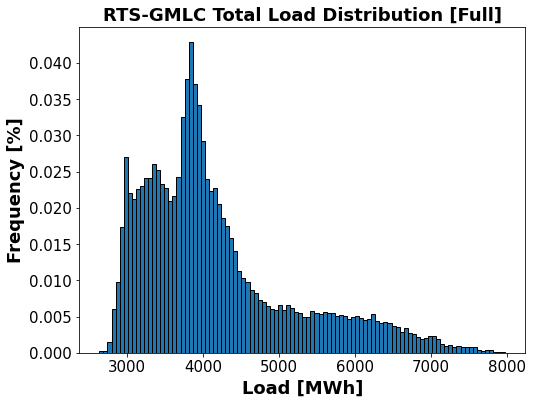

In [16]:
font1 = {'weight':'bold', 'size':18}
df_load = pd.read_csv('REAL_TIME_regional_Load.csv')
total_load = df_load['1'] + df_load['2'] + df_load['3']
tot_load = total_load.to_numpy()
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black')
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('RTS-GMLC Total Load Distribution [Full]', font = font1)
plt.show()

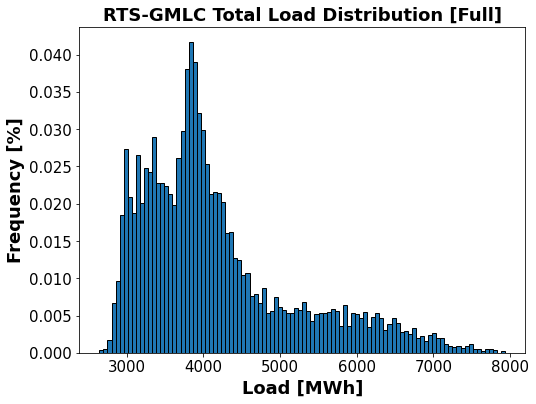

In [17]:
font1 = {'weight':'bold', 'size':18}
df_load = pd.read_csv('Real_Time_load_hourly.csv')
total_load = df_load['1'] + df_load['2'] + df_load['3']
tot_load = total_load.to_numpy()
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black')
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('RTS-GMLC Total Load Distribution [Full]', font = font1)
plt.show()

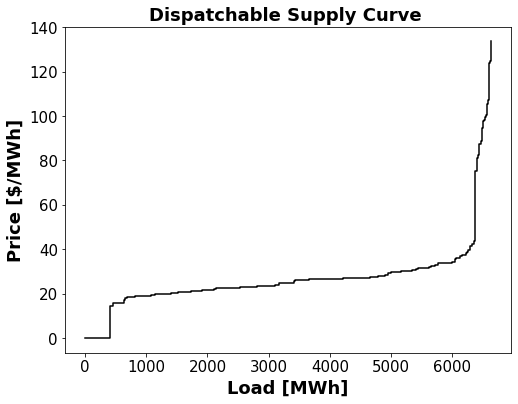

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
font1 = {'weight': 'bold', 'size': 18}
ax.step(cumulate_power, lmp, color='k', zorder = 2)
ax.set_ylabel(r'Price [$/MWh]', font = font1)
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('Dispatchable Supply Curve ', font = font1)
plt.show()

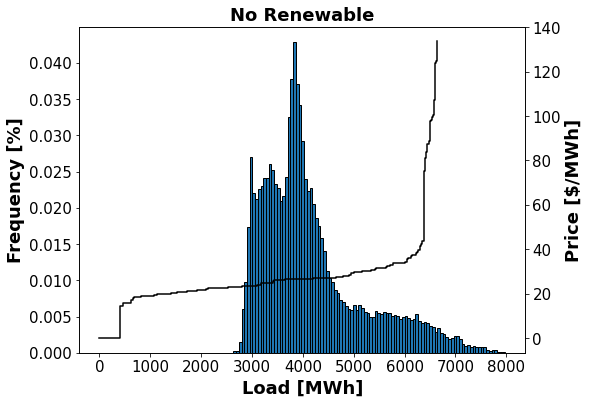

In [210]:
fig, ax = plt.subplots(figsize=(8,6))
font1 = {'weight': 'bold', 'size': 18}
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black', zorder = 1)
ax2 = ax.twinx()
ax2.step(cumulate_power, lmp, color='k', zorder = 2)
ax2.set_ylabel(r'Price [$/MWh]', font = font1)
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('No Renewable', font = font1)
plt.show()

## Add renewables to plot

In [10]:
df_wind = pd.read_csv('Real_Time_wind_hourly.csv')
df_pv = pd.read_csv('Real_Time_pv_hourly.csv')
df_rtpv = pd.read_csv('Real_Time_rtpv_hourly.csv')
df_hydro = pd.read_csv('Real_Time_hydro_hourly.csv')
df_csp = pd.read_csv('Real_Time_csp_hourly.csv')

# extract every generator unit data
def sum_single_renewable(df):
    re_sum_all = []
    for index, row in df.iterrows():
        re_sum = 0
        re_sum = row[df.columns[5:]].sum()
        re_sum_all.append(re_sum)
    
    return re_sum_all

In [11]:
wind_sum_all = sum_single_renewable(df_wind)
pv_sum_all = sum_single_renewable(df_pv)
rtpv_sum_all = sum_single_renewable(df_rtpv)
hydro_sum_all = sum_single_renewable(df_hydro)
csp_sum_all = sum_single_renewable(df_csp)

In [12]:
renew_sum_all = np.array(wind_sum_all) + np.array(pv_sum_all) + np.array(rtpv_sum_all) + np.array(hydro_sum_all) + np.array(csp_sum_all)
renew_sum_all

array([2637.5  , 2620.44 , 2584.862, ...,  560.562,  522.762,  564.602])

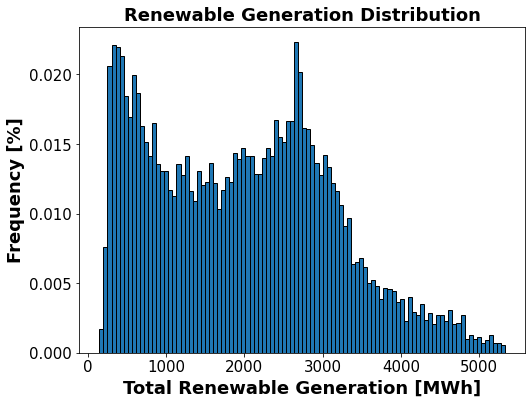

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(renew_sum_all, bins=100, weights=np.ones(len(renew_sum_all)) / len(renew_sum_all), edgecolor='black',)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlabel(r'Total Renewable Generation [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.set_title('Renewable Generation Distribution', font = font1)
plt.show()

In [14]:
re_min = np.min(renew_sum_all)
re_max = np.max(renew_sum_all)
re_med = np.median(renew_sum_all)

cumulate_power_min = cumulate_power.copy()
cumulate_power_min[1:] = cumulate_power_min[1:]+re_min
cumulate_power_max = cumulate_power.copy()
cumulate_power_max[1:] = cumulate_power_max[1:]+re_max
cumulate_power_med = cumulate_power.copy()
cumulate_power_med[1:] = cumulate_power_med[1:]+re_med

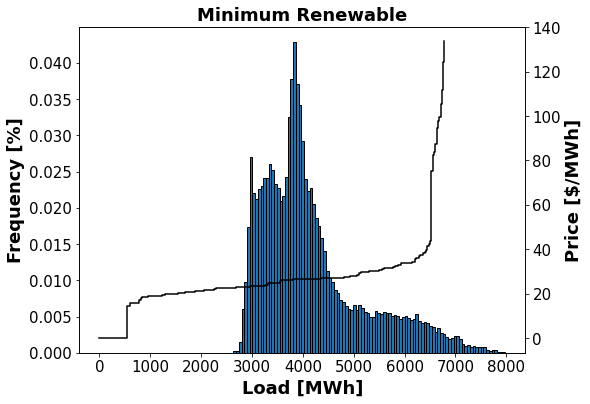

In [200]:
fig, ax = plt.subplots(figsize=(8,6))
font1 = {'weight': 'bold', 'size': 18}
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black', zorder = 1)
ax2 = ax.twinx()
ax2.step(cumulate_power_min, lmp, color='k', zorder = 2)
ax2.set_ylabel(r'Price [$/MWh]', font = font1)
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('Minimum Renewable', font = font1)
plt.show()

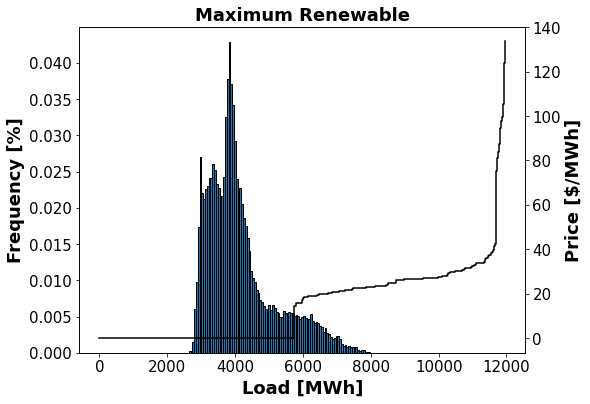

In [201]:
fig, ax = plt.subplots(figsize=(8,6))
font1 = {'weight': 'bold', 'size': 18}
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black', zorder = 1)
ax2 = ax.twinx()
ax2.step(cumulate_power_max, lmp, color='k', zorder = 2)
ax2.set_ylabel(r'Price [$/MWh]', font = font1)
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('Maximum Renewable', font = font1)
plt.show()

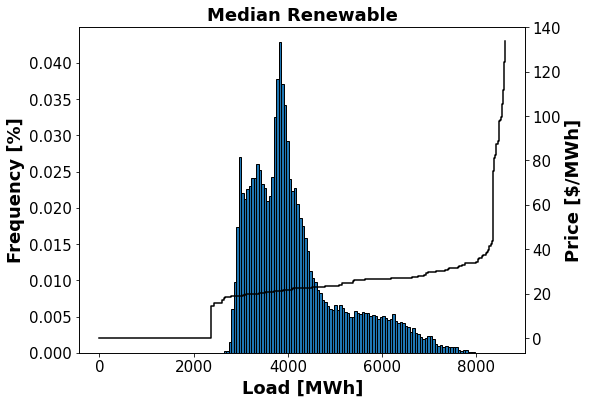

In [203]:
fig, ax = plt.subplots(figsize=(8,6))
font1 = {'weight': 'bold', 'size': 18}
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black', zorder = 1)
ax2 = ax.twinx()
ax2.step(cumulate_power_med, lmp, color='k', zorder = 2)
ax2.set_ylabel(r'Price [$/MWh]', font = font1)
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('Median Renewable', font = font1)
plt.show()

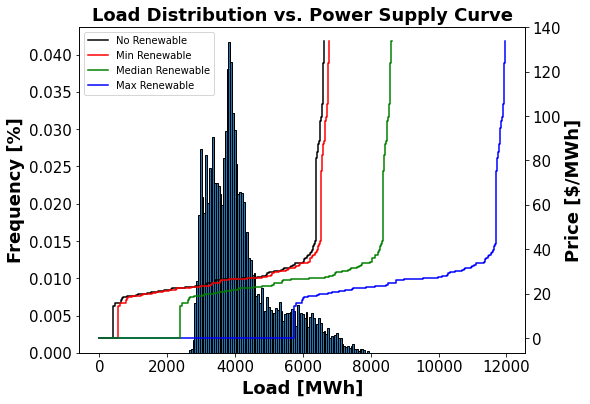

In [22]:
# 4 in 1
fig, ax = plt.subplots(figsize=(8,6))
font1 = {'weight': 'bold', 'size': 18}
ax.hist(tot_load, bins=100, weights=np.ones(len(tot_load)) / len(tot_load), edgecolor='black', zorder = 1)
ax2 = ax.twinx()
ax2.step(cumulate_power, lmp, color='k', zorder=2, label='No Renewable')
ax2.step(cumulate_power_min, lmp, color='r', zorder=3, label='Min Renewable')
ax2.step(cumulate_power_med, lmp, color='g', zorder=5, label='Median Renewable')
ax2.step(cumulate_power_max, lmp, color='b', zorder=4, label='Max Renewable')
ax2.set_ylabel(r'Price [$/MWh]', font = font1)
ax.set_xlabel(r'Load [MWh]', font = font1)
ax.set_ylabel(r'Frequency [%]', font = font1)
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('Load Distribution vs. Power Supply Curve', font = font1)
plt.legend()
plt.show()

## Plot total cost curve

In [45]:
dict_marginal_cost, dict_power = calculate_thermal_marginal_costs(path, include_startup=True)

gen = '101_STEAM_3'
def calculate_piecewise_costs(gen):
    cost = []
    power = []
    cum_cost = 0
    cum_power = 0
    for c, p in zip(dict_marginal_cost[gen], dict_power[gen]):
        cum_cost += p*c
        cum_power += p
        cost.append(cum_cost)
        power.append(cum_power)
    
    return cost, power

(0.997127933092592, [array([[16.466]]), array([331.43808557])])

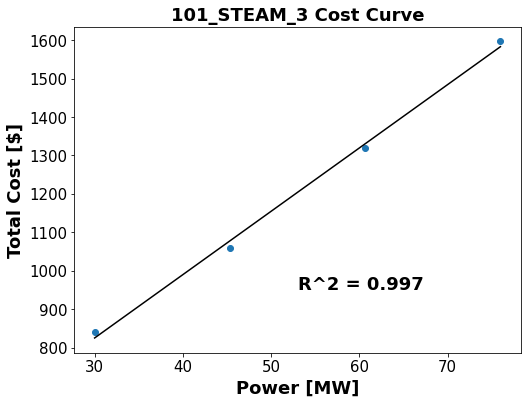

In [70]:
gen = '101_STEAM_3'
from sklearn.linear_model import LinearRegression

def linear_reg_and_plot(gen, plot=True):
    cost, power = calculate_piecewise_costs(gen)
    
    # linear regression
    X = np.array([power]).reshape(-1, 1)
    y = np.array(cost).reshape(-1, 1)
    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)
    reg_param = [reg.coef_, reg.intercept_]
    
    if plot:
        # plot original points
        fig, ax = plt.subplots(figsize=(8,6))
        font1 = {'weight': 'bold', 'size': 18}
        ax.scatter(power, cost)
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.set_xlabel('Power [MW]', font=font1)
        ax.set_ylabel('Total Cost [$]', font=font1)
        ax.set_title(f'{gen} Cost Curve', font=font1)
        ax.text((power[-3]+power[-2])/2, (cost[0]+cost[1])/2, f"R^2 = {np.round(r2, 3)}", font=font1)
        xsp = np.linspace(min(power), max(power))
        ypred = reg.coef_*xsp + reg.intercept_
        ax.plot(xsp, ypred.reshape(-1, 1), c='k')
    
    return r2, reg_param

linear_reg_and_plot(gen, plot=True)

In [94]:
# get regression r2 for all generators
linear_reg_param = {}
linear_reg_r2 = {}
for gen in dict_power.keys():
    r2, reg_param = linear_reg_and_plot(gen, plot=False)
    linear_reg_r2[gen] = r2
    linear_reg_param[gen] = {}
    linear_reg_param[gen]['slope'] = reg_param[0].reshape(-1)[0]
    linear_reg_param[gen]['intercept'] = reg_param[1].reshape(-1)[0]

Text(0, 0.5, 'Values')

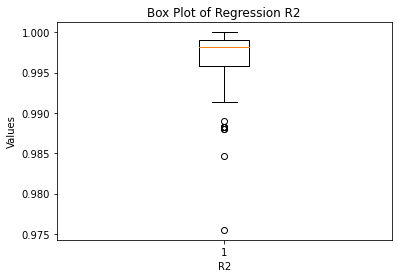

In [97]:
# make a boxplot to show the r2 results
r2_ = []
for gen in linear_reg_r2:
    r2_.append(linear_reg_r2[gen])

plt.boxplot(r2_)
plt.title('Box Plot of Regression R2')
plt.xlabel('R2')
plt.ylabel('Values')

In [96]:
import json

with open("rtsgmle_gen_linear_cost_curve.json", 'w') as f:
    json.dump(linear_reg_param, f)